In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports test")

Imports test


In [5]:
DATA_PATH = "../data/predictive_maintenance.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [6]:
print(df.columns.tolist())
df.info()

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [7]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [8]:
print("Target counts:\n", df["Target"].value_counts())
print("\nTarget rate (mean):", round(df["Target"].mean(), 4))
print("\nTarget %:\n", (df["Target"].value_counts(normalize=True) * 100).round(2))

Target counts:
 Target
0    9661
1     339
Name: count, dtype: int64

Target rate (mean): 0.0339

Target %:
 Target
0    96.61
1     3.39
Name: proportion, dtype: float64


In [9]:
# If you see 'Failure Type' here, that's the leakage column we must drop.
df["Failure Type"].value_counts(dropna=False).head(10)

drop_cols = ["UDI", "Product ID", "Failure Type"]
df_model = df.drop(columns=drop_cols)

print("New shape after dropping leakage/IDs:", df_model.shape)
df_model.head()

New shape after dropping leakage/IDs: (10000, 7)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [10]:
y = df_model["Target"].astype(int)
X = df_model.drop(columns=["Target"])

# Encode machine Type (L/M/H)
X = pd.get_dummies(X, columns=["Type"], drop_first=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (10000, 7)
y shape: (10000,)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train failure rate:", round(y_train.mean(), 4))
print("Test failure rate:", round(y_test.mean(), 4))

Train shape: (7500, 7) Test shape: (2500, 7)
Train failure rate: 0.0339
Test failure rate: 0.034


In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Logistic Regression")
print("Accuracy:", round(lr_acc, 4))
print("F1:", round(lr_f1, 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_pred))

Logistic Regression
Accuracy: 0.8252
F1: 0.2373
Confusion Matrix:
 [[1995  420]
 [  17   68]]


### Baseline Model Interpretation

Logistic Regression establishes a simple interpretable baseline.
Due to class imbalance (~3.4% failures), F1-score is used instead
of accuracy to evaluate performance.

The model prioritizes detecting failures while accepting some
false positives, which aligns with predictive maintenance goals.

### XGBOOST MODEL IMPLEMENTATION

XGBoost
Accuracy: 0.9812
F1: 0.7374
Confusion Matrix:
 [[2387   28]
 [  19   66]]


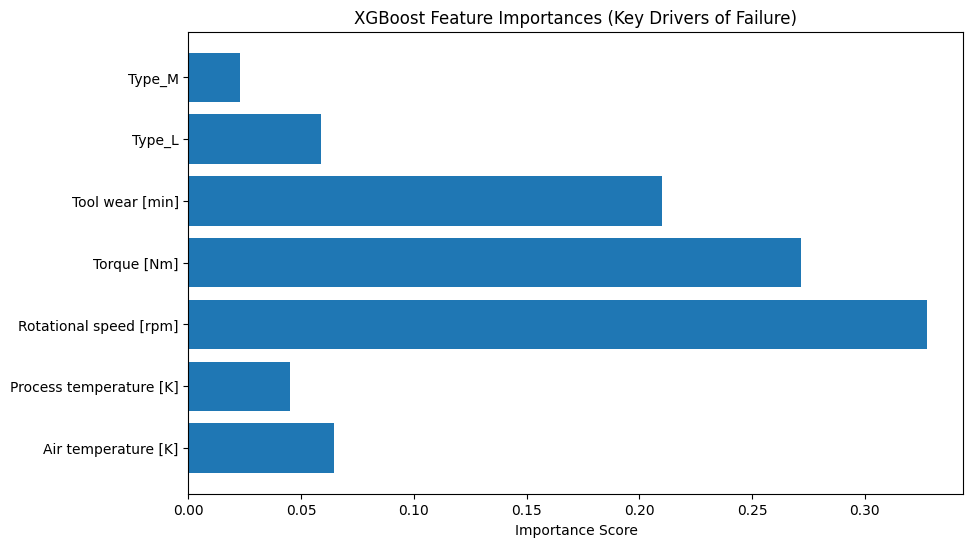

In [22]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

xgb.fit(X_train_scaled, y_train)
xgb_pred = xgb.predict(X_test_scaled)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print("XGBoost")
print("Accuracy:", round(xgb_acc, 4))
print("F1:", round(xgb_f1, 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_pred))

plt.figure(figsize=(10, 6))
plt.barh(X.columns, xgb.feature_importances_)
plt.title("XGBoost Feature Importances (Key Drivers of Failure)")
plt.xlabel("Importance Score")
plt.show()